In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np


In [2]:
#data
from sklearn.datasets import load_iris

iris = load_iris()

## Support Vector Machines
Svm is a binary and multiclass model that classfy data based on his features ranges.it detect pattners on features of each class and save the decision boundary of each class at a specific range for each of his feature.

Let's explore it in pratice;


- Svm is very sensitive to features due his pattner detection between them.so we will use **StandardScaler** to ajust it.

In [3]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

#models:
from sklearn.svm import LinearSVC,SVC

#test,avaliate:
from sklearn.model_selection import train_test_split

Svc_ovr = Pipeline([
    ('scaler',StandardScaler()),
    ('Linearsvc',LinearSVC(loss='hinge',C=1))
])

Svc_ovo = Pipeline ([
    ('scaler',StandardScaler()),
    ('Svc',SVC(kernel='linear'))
])

Scaler = Pipeline([
    ('sca',StandardScaler())])


#data:
x_iris_data = pd.DataFrame(iris['data'][:,(1,3)]) # sepal width,petal width
y_iris_data = pd.DataFrame((iris['target'] == 1).astype(np.float64)) # versicolor , for smvc one vs rest

y_multiclass_iris = pd.DataFrame(iris['target'].astype(np.float64)) # use this in svmc one vs one

x_iris,x_test,y_iris,y_test = train_test_split(x_iris_data,y_iris_data,random_state=33,test_size=0.2)
x_iris_classes,x_test_cl,y_classes,y_classes_test = train_test_split(x_iris_data,y_multiclass_iris,random_state=22,test_size=0.2)

In [4]:
#training :
Svc_ovo.fit(x_iris_classes,y_classes)
Svc_ovr.fit(x_iris,y_iris)


e:\Users\PC\Games\Lib\site-packages\sklearn\utils\validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
e:\Users\PC\Games\Lib\site-packages\sklearn\utils\validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Pipeline(steps=[('scaler', StandardScaler()),
                ('Linearsvc', LinearSVC(C=1, loss='hinge'))])

In [5]:
Scaler.fit(x_iris,y_iris)

Pipeline(steps=[('sca', StandardScaler())])

In [6]:
#predicts

svc1=Svc_ovo.predict(Scaler.transform(x_test))
svc2=Svc_ovr.predict(Scaler.transform(x_test_cl))


Text(0, 0.5, 'petal width')

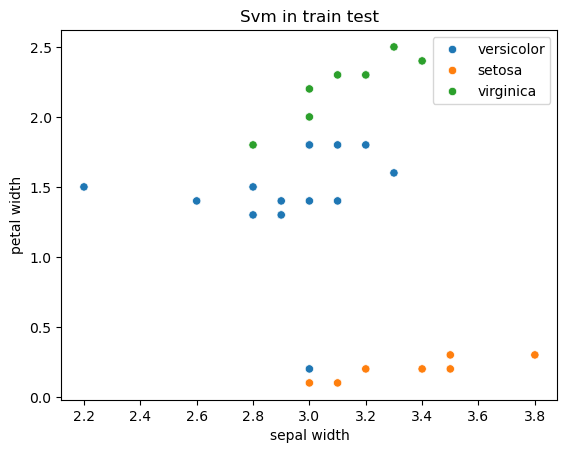

In [7]:
sns.scatterplot(data=x_test,x=x_test[0],y=x_test[1],
        hue=[iris.target_names[i] for i in svc1.astype(int)])
plt.title('Svm in train test')
plt.xlabel('sepal width')
plt.ylabel('petal width')

## Non Linear SVM
When a dataset have only a few features,the model cannot identify difrences between classes clearly.so you can handle with this simply add some features using **PolynomialFeatures**. 

In [8]:
from sklearn.datasets import make_moons
x_m,y_m = make_moons(n_samples=100,noise=0.15) # only 2 features

In [9]:
x_m_train,x_m_test,y_m_train,y_m_test = train_test_split(x_m,y_m,test_size=0.2)

In [10]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score,cross_val_predict
from sklearn.metrics import f1_score

poly_features_svm = Pipeline([
    ('non_linear_features',PolynomialFeatures(degree=3)),
    ('scaler',StandardScaler()),
    ('model',LinearSVC(C=10,loss='hinge'))
])


In [11]:
poly_features_svm.fit(x_m_train,y_m_train)
y_test_predict = poly_features_svm.predict(x_m_test)

In [12]:
cross_val_svm = cross_val_score(estimator=poly_features_svm,X=x_m_train,y=y_m_train,cv=3)
print(f'cross validation on train set : {cross_val_svm}')
print(f'f1 score on test set predicts : {f1_score(y_test_predict,y_m_test)}')

cross validation on train set : [0.88888889 0.92592593 0.96153846]
f1 score on test set predicts : 1.0


e:\Users\PC\Games\Lib\site-packages\sklearn\svm\_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
e:\Users\PC\Games\Lib\site-packages\sklearn\svm\_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


It means that the model generalizes well.

Text(0, 0.5, 'y_test_prediction')

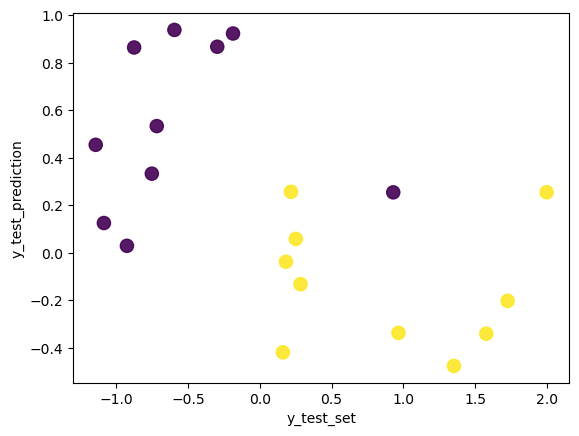

In [13]:
plt.scatter(x=x_m_test[:,0],y=x_m_test[:,1],c=y_test_predict,cmap='viridis',alpha=0.9,s=90)
plt.xlabel('y_test_set')
plt.ylabel('y_test_prediction')

Text(0, 0.5, 'y_test_prediction')

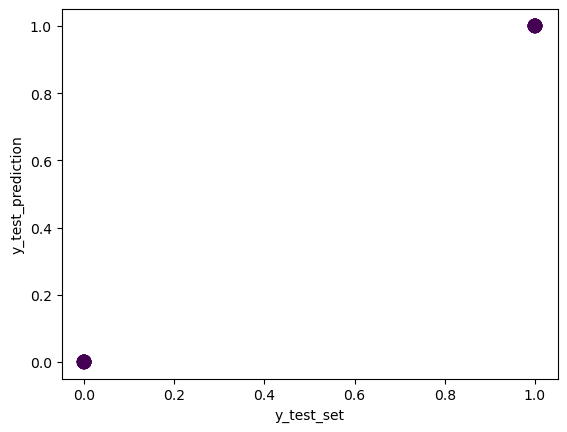

In [14]:
plt.scatter(x=y_m_test,y=y_test_predict,alpha=0.9,s=90,c=[y_m_test - y_test_predict],cmap='viridis')
plt.xlabel('y_test_set')
plt.ylabel('y_test_prediction')

- as you see,Yellow and Purple points have diferents results compared with their original class.

Features are really important to svm.so you should handle it with:
- kernel='poly' + coef0 : controls how model works with features.

kernel poly tell to model compute many features from data without add or create any,while coef controls how the model is affected by features.

this improve model perfomance on complexity datasets with many correlation between a few features.also,model becomes more fast because there's not many new features on data. 

In [ ]:
poly_kernel_svm = Pipeline([
    ('scaler',StandardScaler)
])

svm_poly_2 = SVC(kernel='poly',degree=2,coef0=1,C=5)
svm_poly_2.fit(x_m_train,y_m_train)
predicts2 = svm_poly_2.predict(x_m_test)
results2 = {'cv': cross_val_score(svm_poly_2,x_m_train,y_m_train,cv=2),'f1':f1_score(y_m_test,predicts2)}

svm_poly_5 = SVC(kernel='poly',degree=10,coef0=50,C=5)
svm_poly_5.fit(x_m_train,y_m_train)
predicts5 = svm_poly_5.predict(x_m_test)
results5 = {'cv': cross_val_score(svm_poly_5,x_m_train,y_m_train,cv=2),'f1':f1_score(y_m_test,predicts5)}

svm_poly_52 = SVC(kernel='poly',degree=2,coef0=50,C=5)
svm_poly_52.fit(x_m_train,y_m_train)
predicts52 = svm_poly_52.predict(x_m_test)
results52 = {'cv': cross_val_score(svm_poly_52,x_m_train,y_m_train,cv=2),'f1':f1_score(y_m_test,predicts52)}

svm_poly_25 = SVC(kernel='poly',degree=10,coef0=1,C=5)
svm_poly_25.fit(x_m_train,y_m_train)
predicts25 = svm_poly_25.predict(x_m_test)
results25 = {'cv': cross_val_score(svm_poly_25,x_m_train,y_m_train,cv=2),'f1':f1_score(y_m_test,predicts25)}

C:\Users\augusto\AppData\Local\Temp\ipykernel_12036\3485757552.py:5: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()
C:\Users\augusto\AppData\Local\Temp\ipykernel_12036\3485757552.py:10: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()
C:\Users\augusto\AppData\Local\Temp\ipykernel_12036\3485757552.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()
C:\Users\augusto\AppData\Local\Temp\ipykernel_12036\3485757552.py:20: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argume

{'cv': array([0.9 , 0.85]), 'f1': 0.8888888888888888}
{'cv': array([0.95 , 0.925]), 'f1': 0.9473684210526315}
{'cv': array([0.9 , 0.85]), 'f1': 0.8888888888888888}
{'cv': array([0.925, 0.975]), 'f1': 0.9473684210526315}


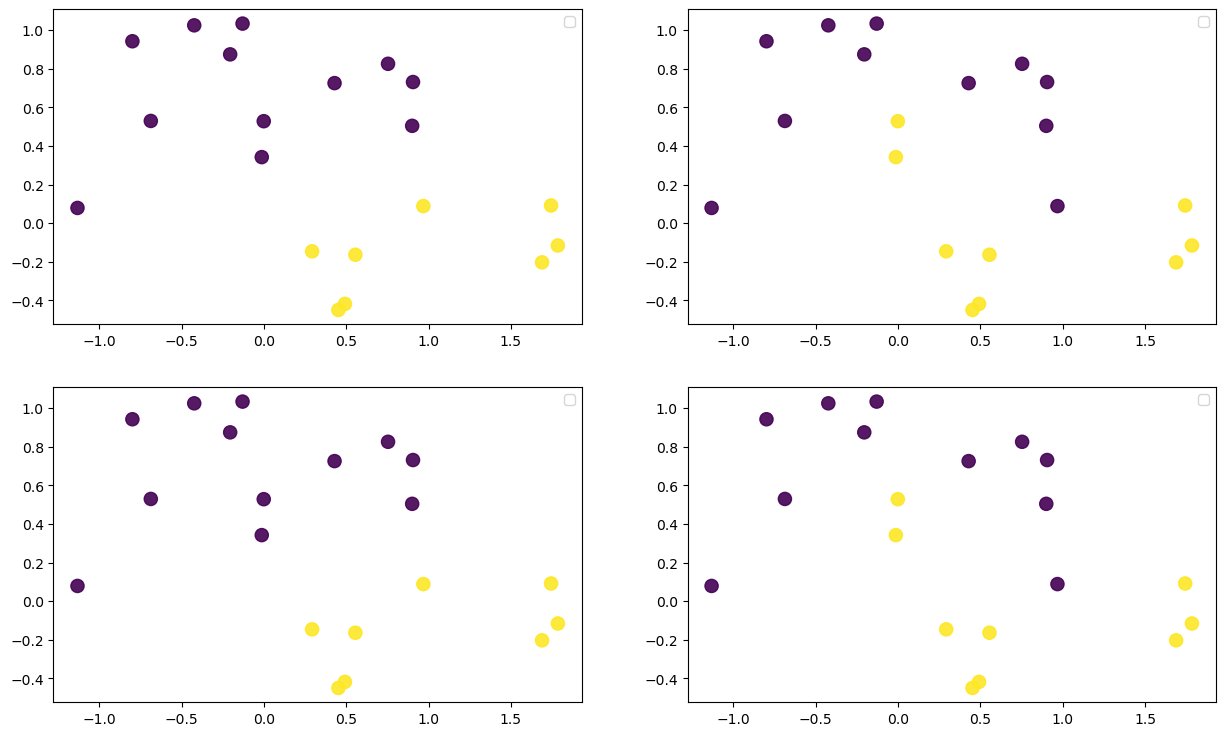

In [ ]:
plt.figure(figsize=(15,9))

plt.subplot(2,2,1)
plt.scatter(x=x_m_test[:,0],y=x_m_test[:,1],c=predicts2,cmap='viridis',alpha=0.9,s=90,)
plt.legend()
print(results2)

plt.subplot(2,2,2)
plt.scatter(x=x_m_test[:,0],y=x_m_test[:,1],c=predicts5,cmap='viridis',alpha=0.9,s=90,)
plt.legend()
print(results5)

plt.subplot(2,2,3)
plt.scatter(x=x_m_test[:,0],y=x_m_test[:,1],c=predicts52,cmap='viridis',alpha=0.9,s=90,)
plt.legend()
print(results52)

plt.subplot(2,2,4)
plt.scatter(x=x_m_test[:,0],y=x_m_test[:,1],c=predicts25,cmap='viridis',alpha=0.9,s=90,)
plt.legend()
print(results25)

C:\Users\augusto\AppData\Local\Temp\ipykernel_12036\245030265.py:4: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


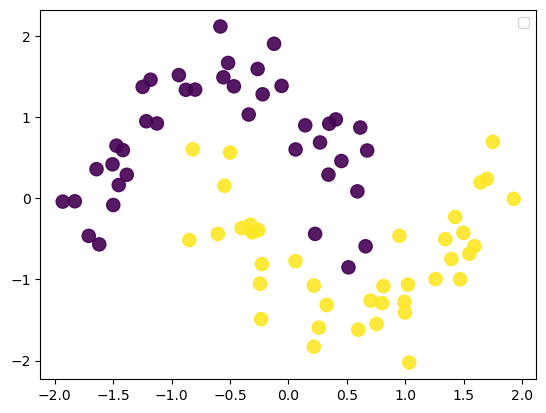

In [ ]:
# original
x_data=StandardScaler().fit_transform(x_m_train,y_m_train)
plt.scatter(x=x_data[:,0],y=x_data[:,1],c=y_m_train,cmap='viridis',alpha=0.9,s=90,)
plt.legend()

## Rbf Kernel and Regression
Other way for compute non linear data is using gaussian rbf kernel.the rbf kernel calculates decision boundary using the distance between features,being affected by new data using hyperparameter ** gamma**.this meansures how long each data point is from other.

- Let's view it using **Gridsearch**;

In [ ]:
from sklearn.model_selection import GridSearchCV

svm_gs = SVC()
svm_parans = {'C':[0.001,1,1000],'kernel':['linear','rbf'],'gamma':[0.1,5,10]}

Svm_general = GridSearchCV(svm_gs,svm_parans,scoring='f1',cv=3)
Svm_general.fit(x_data,y_m_train)


GridSearchCV(cv=3, estimator=SVC(),
             param_grid={'C': [0.001, 1, 1000], 'gamma': [0.1, 5, 10],
                         'kernel': ['linear', 'rbf']},
             scoring='f1')

In [ ]:
print(Svm_general.best_estimator_,Svm_general.best_score_,Svm_general.best_params_)

SVC(C=1000, gamma=5) 0.9620132953466287 {'C': 1000, 'gamma': 5, 'kernel': 'rbf'}


### Regression

In [ ]:
from sklearn.svm import SVR

svm_rg = SVR(epsilon=1.5)
svm_rg_poly = SVR(epsilon=1.5,kernel='poly',degree=2,C=100)
svm_rg.fit(x_data,y_m_train)
svm_rg_poly.fit(x_data,y_m_train)


SVR(C=100, degree=2, epsilon=1.5, kernel='poly')